In [59]:
#import the libreries
import numpy as np

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [61]:
#Load data 
df=pd.read_csv("C:/Users/91936/Downloads/loan_approval_dataset.csv")
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [62]:
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [63]:
#dropping loan_id column
df.drop(['loan_id'],axis=1,inplace=True)

In [64]:
df.head(4)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected


In [65]:
#Checking null value in data
df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [67]:
df.shape

(4269, 12)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0    no_of_dependents          4269 non-null   int64 
 1    education                 4269 non-null   object
 2    self_employed             4269 non-null   object
 3    income_annum              4269 non-null   int64 
 4    loan_amount               4269 non-null   int64 
 5    loan_term                 4269 non-null   int64 
 6    cibil_score               4269 non-null   int64 
 7    residential_assets_value  4269 non-null   int64 
 8    commercial_assets_value   4269 non-null   int64 
 9    luxury_assets_value       4269 non-null   int64 
 10   bank_asset_value          4269 non-null   int64 
 11   loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [69]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [12]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [70]:
#data analysis for Educationwise Loan Status
df_education=df.groupby([' education',' loan_status'])[' loan_status'].agg("count")

In [71]:
df_edu_final=df_education.reset_index(name='loan_status_count')

In [72]:
df_edu_final

,education,loan_status,loan_status_count
0,Graduate,Approved,1339
1,Graduate,Rejected,805
2,Not Graduate,Approved,1317
3,Not Graduate,Rejected,808


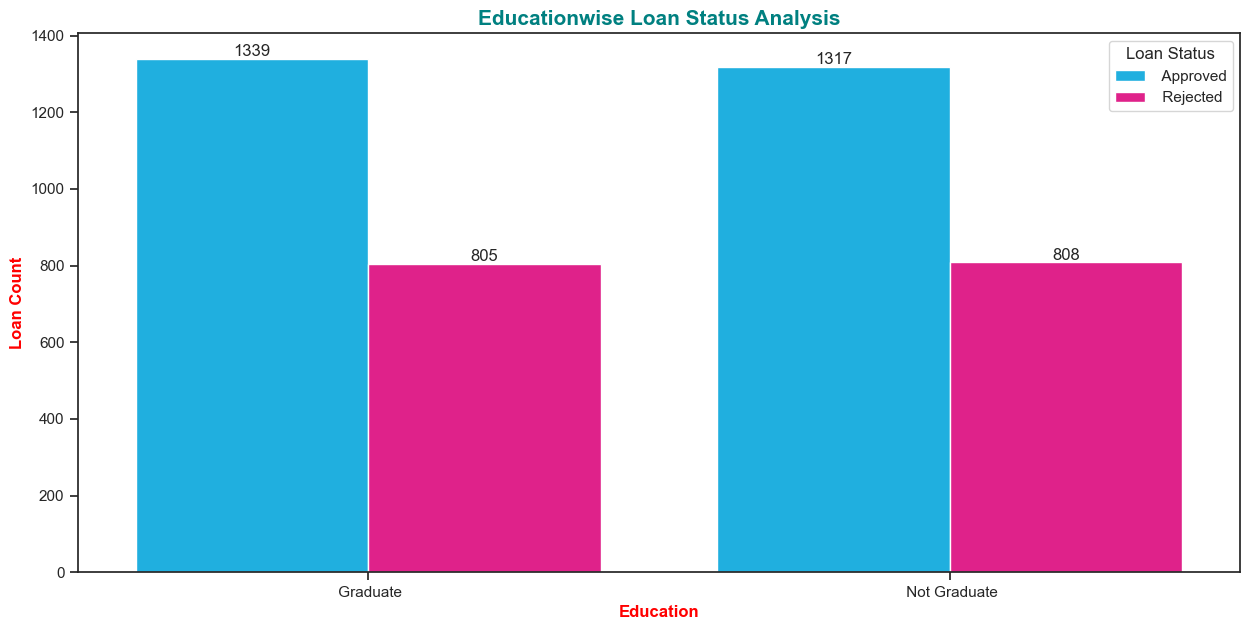

In [73]:
#plotting Educationwise Loan Status
sns.set_style("white")
sns.set_theme(style="ticks")
plt.figure(figsize=(15,7))
palette_edu=['deepskyblue','xkcd:hot pink']
ax=sns.barplot(x=' education',y='loan_status_count',hue=' loan_status',data=df_edu_final,palette=palette_edu)
for container in ax.containers:
    ax.bar_label(container)
ax.set_xlabel("Education",fontweight="bold",size=12,color="red")
ax.set_ylabel("Loan Count",fontweight="bold",size=12,color="red")

plt.title("Educationwise Loan Status Analysis",size=15,fontweight="bold",color="teal")
plt.legend(title="Loan Status")
plt.show()


In [74]:
df_approved=df[(df[' loan_status']==' Approved')]

In [75]:
df_rejected=df[(df[' loan_status']==' Rejected')]

In [76]:
df_approved_final=df_approved.groupby([' self_employed'])[' self_employed'].agg("count").to_frame()

In [77]:
lstapproved_labels=df_approved_final.index.to_list()

In [78]:
lstapproved_values=df_approved_final[' self_employed'].to_list()


In [79]:
#updating values of self-employed data list of approved data
lstapproved_labels=[w.replace('Yes','Self-Employed') for w in lstapproved_labels]
lstapproved_labels=[w.replace('No','Not Self-Employed') for w in lstapproved_labels]

In [80]:
lstapproved_labels

[' Not Self-Employed', ' Self-Employed']

In [81]:
df_rejected_final=df_rejected.groupby([' self_employed'])[' self_employed'].agg("count").to_frame()

In [82]:
lstrejected_labels=df_rejected_final.index.to_list()

In [84]:
lstrejected_values=df_rejected_final[' self_employed'].to_list()

In [85]:
lstrejected_labels

[' No', ' Yes']

Text(0.5, 1.0, 'Rejected Loans')

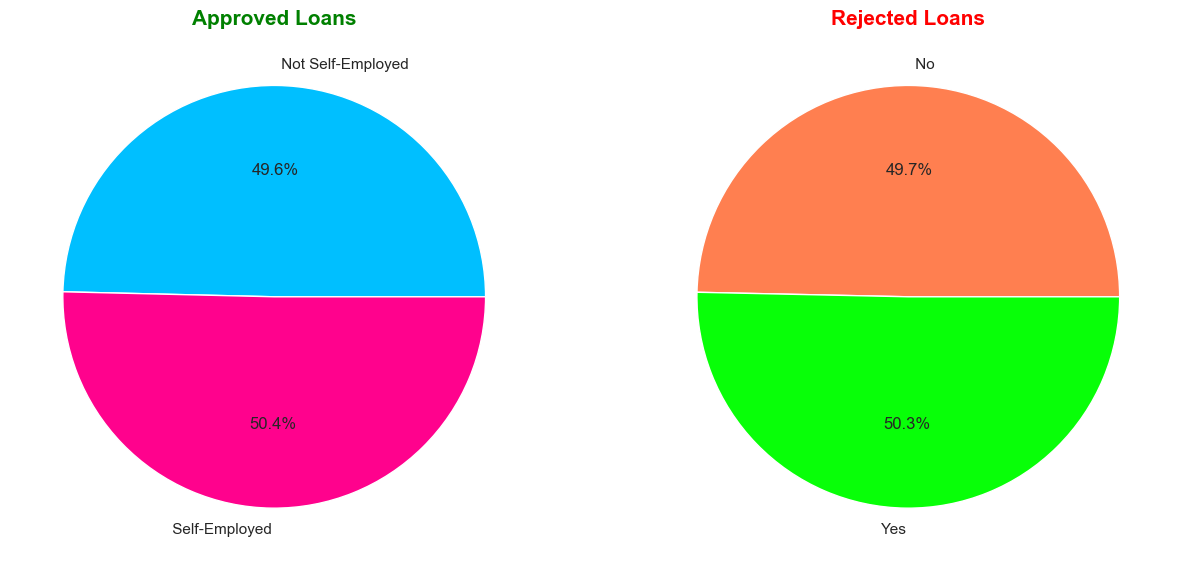

In [86]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,10))

labels1 = lstapproved_labels
values1 = lstapproved_values
ax1.pie(values1,labels = labels1,autopct = '%1.1f%%',colors=['deepskyblue','xkcd:hot pink']) #plot first pie
ax1.set_title('Approved Loans',fontweight="bold",size=15,color='green')

labels2 = lstrejected_labels
values2 = lstrejected_values
ax2.pie(values2,labels = labels2,autopct = '%1.1f%%',colors=['coral','xkcd:fluorescent green']) #plot second pie
ax2.set_title('Rejected Loans',fontweight="bold",color="red",size=15)

In [87]:
df.shape

(4269, 12)

In [89]:
#data prepare for Annual Income & Loan Amount & Approval Status Analysis
df['income_annum(lakh)']=df[' income_annum']/100000
df['loan_amount(lakh)']=df[' loan_amount']/100000

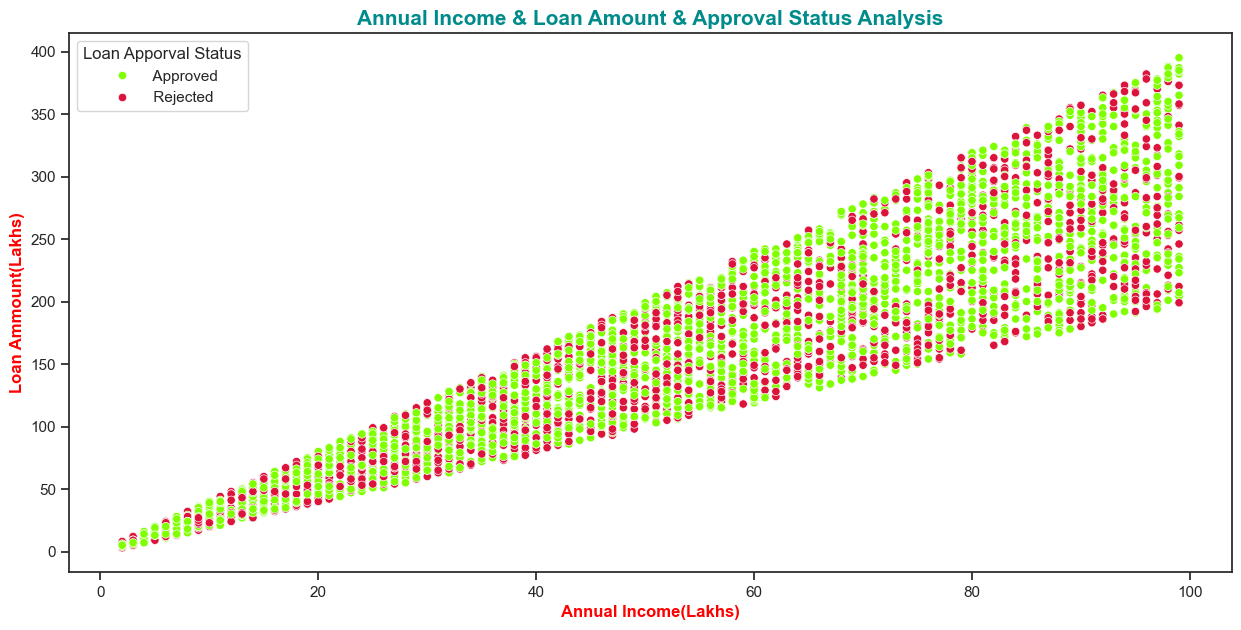

In [90]:
#plotting data of Annual Income & Loan Amount & Approval Status Analysis
plt.figure(figsize=(15,7))
palette_amount=["chartreuse","crimson"]
ax=sns.scatterplot(x="income_annum(lakh)",y="loan_amount(lakh)",hue=" loan_status",data=df,palette=palette_amount)

plt.xlabel("Annual Income(Lakhs)",size=12,fontweight="bold",color="red")
plt.ylabel("Loan Ammount(Lakhs)",size=12,fontweight="bold",color="red")

plt.title("Annual Income & Loan Amount & Approval Status Analysis",size=15,fontweight="bold",color='darkcyan')
plt.legend(title="Loan Apporval Status")
plt.show()

In [91]:
df_dependent=df.groupby([' no_of_dependents',' loan_status'])[' loan_status'].agg("count")

In [92]:
df_dependents_final=df_dependent.reset_index(name=' loan_status_count')

In [93]:
df_dependents_final

,no_of_dependents,loan_status,loan_status_count
0,0,Approved,457
1,0,Rejected,255
2,1,Approved,430
3,1,Rejected,267
4,2,Approved,441
5,2,Rejected,267
6,3,Approved,457
7,3,Rejected,270
8,4,Approved,465
9,4,Rejected,287


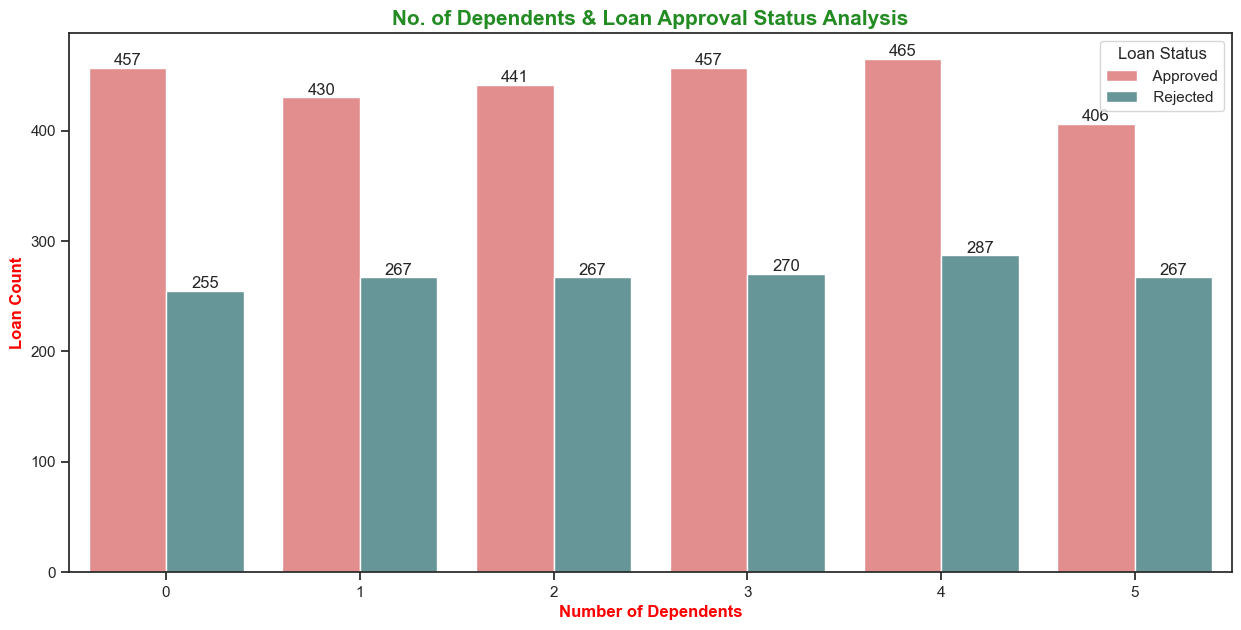

In [94]:
#plotting No. of Dependents & Loan Approval Status Analysis
sns.set_style("white")
sns.set_theme(style="ticks")
#sns.set_color_codes("bright")
palette_dependent = ["lightcoral", "cadetblue"]

plt.figure(figsize=(15,7))
ax=sns.barplot(x=' no_of_dependents',y=' loan_status_count',hue=' loan_status',data=df_dependents_final,palette=palette_dependent)
for container in ax.containers:
    ax.bar_label(container)

ax.set_xlabel("Number of Dependents",size=12,fontweight="bold",color="red")
ax.set_ylabel("Loan Count",size=12,fontweight="bold",color="red")

plt.title("No. of Dependents & Loan Approval Status Analysis",size=15,fontweight="bold",color="forestgreen")
plt.legend(title="Loan Status")
plt.show()

In [95]:
df_term_approved_cnt=df_approved.groupby([' loan_term'])[' loan_term'].agg("count")

In [96]:
df_term_approved_cnt_final=df_term_approved_cnt.reset_index(name="Cnt")

In [97]:
df_term_approved_cnt_final

,loan_term,Cnt
0,2,315
1,4,366
2,6,282
3,8,220
4,10,229
5,12,276
6,14,239
7,16,236
8,18,257
9,20,236


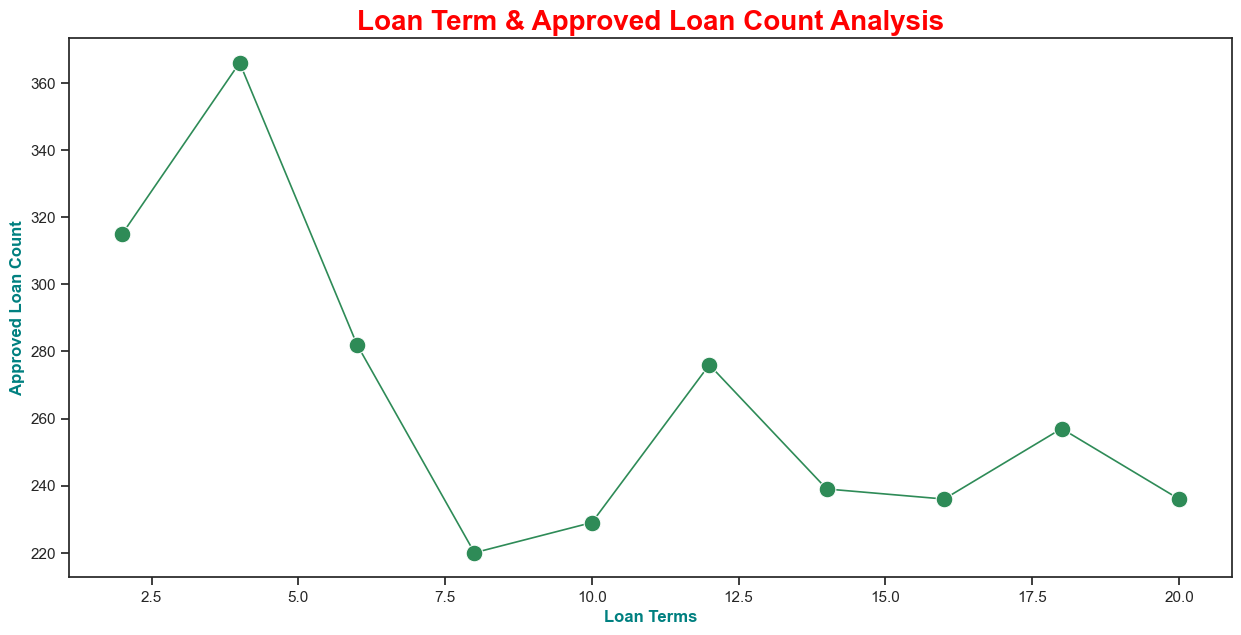

In [98]:
#plotting Loan Term & Approved Loan Count Analysis
sns.set_style("white")
sns.set_theme(style="ticks")
fig=plt.figure(figsize=(15,7))
line=sns.lineplot(x=" loan_term",y="Cnt",data=df_term_approved_cnt_final,marker="o",
                 color="seagreen",linewidth=1.2,markersize=12)

plt.title("Loan Term & Approved Loan Count Analysis",fontweight="bold",size=20,color="red")
plt.xlabel("Loan Terms",fontweight="bold",size=12,color="teal")
plt.ylabel("Approved Loan Count",fontweight="bold",size=12,color="teal")
plt.show()  

In [101]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status',
       'income_annum(lakh)', 'loan_amount(lakh)'],
      dtype='object')

In [104]:
df.drop(['income_annum(lakh)','loan_amount(lakh)'],inplace=True,axis=1)

In [105]:
encoder=LabelEncoder()

s=df[' self_employed']
s

0         No
1        Yes
2         No
3         No
4        Yes
        ... 
4264     Yes
4265     Yes
4266      No
4267      No
4268      No
Name:  self_employed, Length: 4269, dtype: object

In [106]:
#Non-Self Employed = 0, self-employed=1
df[' self_employed']=encoder.fit_transform(s)


In [107]:
r=df[' education']
r

0            Graduate
1        Not Graduate
2            Graduate
3            Graduate
4        Not Graduate
            ...      
4264         Graduate
4265     Not Graduate
4266     Not Graduate
4267     Not Graduate
4268         Graduate
Name:  education, Length: 4269, dtype: object

In [108]:
#graduate=0, non graduate=1
df[' education']=encoder.fit_transform(r)

In [109]:
df.shape

(4269, 12)

In [110]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [111]:
v=df[' loan_status']
v

0        Approved
1        Rejected
2        Rejected
3        Rejected
4        Rejected
          ...    
4264     Rejected
4265     Approved
4266     Rejected
4267     Approved
4268     Approved
Name:  loan_status, Length: 4269, dtype: object

In [112]:
df[' loan_status']=encoder.fit_transform(v)

In [113]:
df.head(6)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1
5,0,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,1


In [114]:
df_RF=df.select_dtypes(['int','float'])

In [115]:
df_RF.shape

(4269, 12)

In [116]:
df_RF

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,1
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,0


In [117]:
#defining features
X=df_RF.drop([' loan_status'],axis=1)
X

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000
...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000


In [118]:
X.shape

(4269, 11)

In [119]:
#defining target
y=df.iloc[0:,11:12]
y

,loan_status
0,0
1,1
2,1
3,1
4,1
...,...
4264,1
4265,0
4266,1
4267,0


In [120]:
#splitting data in train and test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [121]:
cls=RandomForestClassifier(n_estimators=300,criterion='entropy',random_state=0)

In [122]:
cls.fit(X_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(criterion='entropy', n_estimators=300, random_state=0)

In [123]:
y_pred=cls.predict(X_test)

In [72]:
y_pred

array([0, 0, 0, ..., 0, 1, 0])

In [124]:
#preparing confusion matrix
results=confusion_matrix(y_test,y_pred)

In [125]:
print(results)

[[654   5]
 [ 11 398]]


<Axes: >

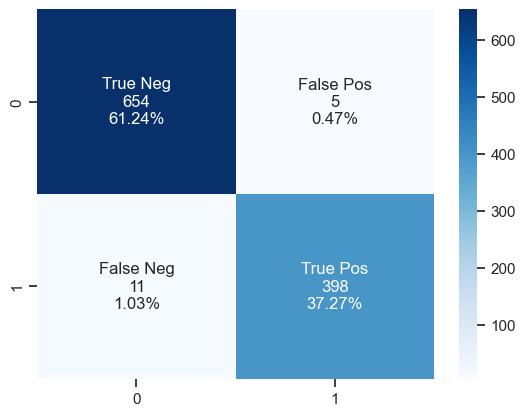

In [126]:
#plotting confusion matrix
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                results.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     results.flatten()/np.sum(results)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(results, annot=labels, fmt='', cmap='Blues')

In [127]:
#Accuracy of model
print('accuracy : ',accuracy_score(y_test,y_pred))

accuracy :  0.9850187265917603


In [131]:
IntAccuracy=accuracy_score(y_test,y_pred)
IntAccuracyFinal=IntAccuracy*100

In [128]:
#verifying loan approval with sample data[output 0 is for approved]
y_pred_approve=cls.predict([[3,0,0,9200000,23900000,8,780,18200000,17600000,22700000,12800000]])
y_pred_approve

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [129]:
#verifying loan rejection with sample data[output 1 is for rejection]
y_pred_reject=cls.predict([[0,1,1,1000,1000000,20,120,1000,1000,1000,2000]])
y_pred_reject

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [130]:
#sample tkinter GUI for loan approval/rejection prediction
from tkinter import *
from tkinter import ttk
from tkinter import messagebox

top=Tk()
top.geometry('700x700')
top.title("Loan Approval Prediction")

def funcLoanApproval():
    strEducation=cmbEducation.get()
    if(strEducation=='Graduate'):
        IntEducation=0
    else:
        IntEducation=1
    
    strSelfEmployed=cmbEmployment.get()
    if(strSelfEmployed=='No'):
        IntEmployed=0
    else:
        IntEmployed=1
    #print(IntEmployed)
    
    y_pred=cls.predict([[entDependent.get(),IntEducation,IntEmployed,entAnnualIncome.get(),
                        entLoanAmount.get(),entLoanTerm.get(),entCibilScore.get(),entResidentialAsset.get(),
                        entCommAsset.get(),entLuxeryAsset.get(),entBankAsset.get()]])
     
    if(y_pred==0):
        txtPredResult.insert(END,"Loan will be Approved")
    else:
        txtPredResult.insert(END,"Loan will be Rejected")
    
    strAccuracy='{0:.2f}'.format(IntAccuracyFinal),'%'
    txtModelAccuracy.insert(END,strAccuracy)

lblHeader=Label(top,text="Loan Approval Prediction",bg='orange', fg='white',font=('Verdana 20 bold'))
lblHeader.place(x=200,y=20)

lblDependent=Label(top,text="No. of Dependents",bg='orange', fg='white',font=('Verdana 10 bold'))
lblDependent.place(x=200,y=120)

entDependent=Entry(top,font=('Verdana 10'))
entDependent.place(x=360,y=120)

lblEducation=Label(top,text="Education",bg='orange', fg='white',font=('Verdana 10 bold'))
lblEducation.place(x=200,y=160)

lsEducation=['Graduate','Non-Graduate']
cmbEducation=ttk.Combobox(top,values=lsEducation)
cmbEducation.place(x=360,y=160)
cmbEducation.current(0)

lblEmployment=Label(top,text="Self Employed",bg='orange', fg='white',font=('Verdana 10 bold'))
lblEmployment.place(x=200,y=200)

lsEmployment=['Yes','No']
cmbEmployment=ttk.Combobox(top,values=lsEmployment)
cmbEmployment.place(x=360,y=200)
cmbEmployment.current(0)

lblAnnualIncome=Label(top,text="Annual Income",bg='orange', fg='white',font=('Verdana 10 bold'))
lblAnnualIncome.place(x=200,y=240)

entAnnualIncome=Entry(top,font=('Verdana 10'))
entAnnualIncome.place(x=360,y=240)

lblLoanAmount=Label(top,text="Loan Amount",bg='orange', fg='white',font=('Verdana 10 bold'))
lblLoanAmount.place(x=200,y=280)

entLoanAmount=Entry(top,font=('Verdana 10'))
entLoanAmount.place(x=360,y=280)

lblLoanTerm=Label(top,text="Loan Term",bg='orange', fg='white',font=('Verdana 10 bold'))
lblLoanTerm.place(x=200,y=320)

entLoanTerm=Entry(top,font=('Verdana 10'))
entLoanTerm.place(x=360,y=320)

lblCibilScore=Label(top,text="Cibil Score",bg='orange', fg='white',font=('Verdana 10 bold'))
lblCibilScore.place(x=200,y=360)

entCibilScore=Entry(top,font=('Verdana 10'))
entCibilScore.place(x=360,y=360)

lblResidentialAsset=Label(top,text="Residential Asset Value",bg='orange', fg='white',font=('Verdana 10 bold'))
lblResidentialAsset.place(x=200,y=400)

entResidentialAsset=Entry(top,font=('Verdana 10'))
entResidentialAsset.place(x=400,y=400)

lblCommAsset=Label(top,text="Commercial Asset Value",bg='orange', fg='white',font=('Verdana 10 bold'))
lblCommAsset.place(x=200,y=440)

entCommAsset=Entry(top,font=('Verdana 10'))
entCommAsset.place(x=400,y=440)

lblLuxeryAsset=Label(top,text="Luxary Asset Value",bg='orange', fg='white',font=('Verdana 10 bold'))
lblLuxeryAsset.place(x=200,y=480)

entLuxeryAsset=Entry(top,font=('Verdana 10'))
entLuxeryAsset.place(x=400,y=480)

lblBankAsset=Label(top,text="Bank Asset Value",bg='orange', fg='white',font=('Verdana 10 bold'))
lblBankAsset.place(x=200,y=520)

entBankAsset=Entry(top,font=('Verdana 10'))
entBankAsset.place(x=400,y=520)

btnSubmit=Button(top,text='Predict',bg='lime green',fg='white', font=('Verdana 12 bold'),command=lambda : funcLoanApproval())
btnSubmit.place(x=300,y=550)

lblPredResult=Label(top,text="Prediction Result",bg='orange', fg='white',font=('Verdana 10 bold'))
lblPredResult.place(x=200,y=590)

txtPredResult=Text(height=1,width=30,fg='black',font=('Verdana 10'))
txtPredResult.place(x=350,y=590)

lblModelAccuracy=Label(top,text="Prediction Model Accuracy",bg='orange', fg='white',font=('Verdana 10 bold'))
lblModelAccuracy.place(x=200,y=630)

txtModelAccuracy=Text(height=1,width=30,fg='black',font=('Verdana 10'))
txtModelAccuracy.place(x=400,y=630)

top.config(bg='teal')
top.mainloop()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
Exception in Tkinter callback
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\tkinter\__init__.py", line 1968, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "C:\Users\91936\AppData\Local\Temp\ipykernel_17060\1407776778.py", line 109, in <lambda>
    btnSubmit=Button(top,text='Predict',bg='lime green',fg='white', font=('Verdana 12 bold'),command=lambda : funcLoanApproval())
                                                                                                              ^^^^^^^^^^^^^^^^^^
  File "C:\Users\91936\AppData\Local\Temp\ipykernel_17060\1407776778.py", line 33, in funcLoanApproval
    strAccuracy='{0:.2f}'.format(IntAccuracyFinal),'%'
                                 ^^^^^^^^^^^^^^^^
NameError: name 'IntAccuracyFinal' is not defi

In [ ]:
#3,0,0,9200000,23900000,8,780,18200000,17600000,22700000,12800000